# 02 — OFI Computation

Compute proxy Order Flow Imbalance using the tick rule.
Validate distributions, autocorrelation, and cross-asset correlations.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TICKERS, OFI_HORIZONS
from src.data_loader import load_processed
from src.ofi import sign_volume, compute_ofi, compute_all_ofi

sns.set_style('whitegrid')
%matplotlib inline

## 2.1 Load aligned panel

In [2]:
panel = load_processed()

# Extract individual ticker DataFrames
ticker_data = {}
for ticker in TICKERS:
    ticker_data[ticker] = panel[ticker].copy()

print(f"Panel: {panel.shape[0]:,} bars, {panel.index.min().date()} to {panel.index.max().date()}")

Panel: 98,625 bars, 2024-01-02 to 2025-01-02


## 2.2 Tick rule sanity check

In [3]:
# Check tick rule on NIFTY
nifty_signed = sign_volume(ticker_data['NIFTY'])

print("Direction distribution:")
print(nifty_signed['direction'].value_counts(normalize=True).round(3))
print(f"\nTotal buy vol:  {nifty_signed['buy_vol'].sum():,.0f}")
print(f"Total sell vol: {nifty_signed['sell_vol'].sum():,.0f}")
print(f"Ratio: {nifty_signed['buy_vol'].sum() / nifty_signed['sell_vol'].sum():.3f}")

Direction distribution:
direction
-1.0    0.503
 1.0    0.497
 0.0    0.000
Name: proportion, dtype: float64

Total buy vol:  2,240,615,092
Total sell vol: 2,279,626,710
Ratio: 0.983


## 2.3 Compute OFI at all horizons

In [4]:
ofi_df = compute_all_ofi(ticker_data)
print(f"OFI DataFrame: {ofi_df.shape}")
ofi_df.head()

OFI DataFrame: (98625, 25)


,NIFTY_ofi_1,NIFTY_ofi_5,NIFTY_ofi_15,NIFTY_ofi_30,NIFTY_ofi_60,BANKNIFTY_ofi_1,BANKNIFTY_ofi_5,BANKNIFTY_ofi_15,BANKNIFTY_ofi_30,BANKNIFTY_ofi_60,...,RELIANCE_ofi_1,RELIANCE_ofi_5,RELIANCE_ofi_15,RELIANCE_ofi_30,RELIANCE_ofi_60,INFY_ofi_1,INFY_ofi_5,INFY_ofi_15,INFY_ofi_30,INFY_ofi_60
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-02 09:15:00,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2024-01-02 09:16:00,-1.0,0.00000,0.0,0.0,0.0,-1.0,0.000000,0.0,0.0,0.0,...,-1.0,0.000000,0.0,0.0,0.0,-1.0,0.000000,0.0,0.0,0.0
2024-01-02 09:17:00,1.0,0.00000,0.0,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,...,1.0,0.000000,0.0,0.0,0.0,1.0,0.000000,0.0,0.0,0.0
2024-01-02 09:18:00,1.0,0.00000,0.0,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,...,1.0,0.000000,0.0,0.0,0.0,1.0,0.000000,0.0,0.0,0.0
2024-01-02 09:19:00,-1.0,-0.00144,0.0,0.0,0.0,-1.0,0.000086,0.0,0.0,0.0,...,-1.0,-0.000589,0.0,0.0,0.0,-1.0,-0.002781,0.0,0.0,0.0


## 2.4 OFI distributions by horizon

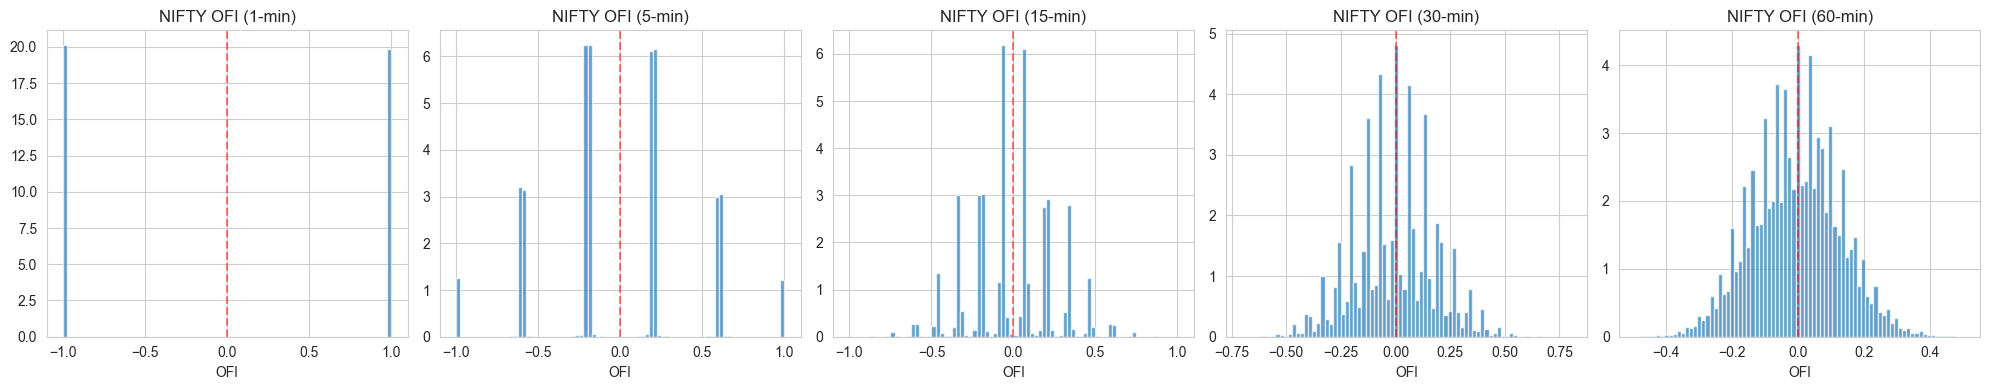

In [5]:
fig, axes = plt.subplots(1, len(OFI_HORIZONS), figsize=(4 * len(OFI_HORIZONS), 4))

for ax, h in zip(axes, OFI_HORIZONS):
    col = f'NIFTY_ofi_{h}'
    ofi_df[col].dropna().hist(bins=80, ax=ax, alpha=0.7, density=True)
    ax.set_title(f'NIFTY OFI ({h}-min)')
    ax.set_xlabel('OFI')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/figures/ofi_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Autocorrelation of OFI

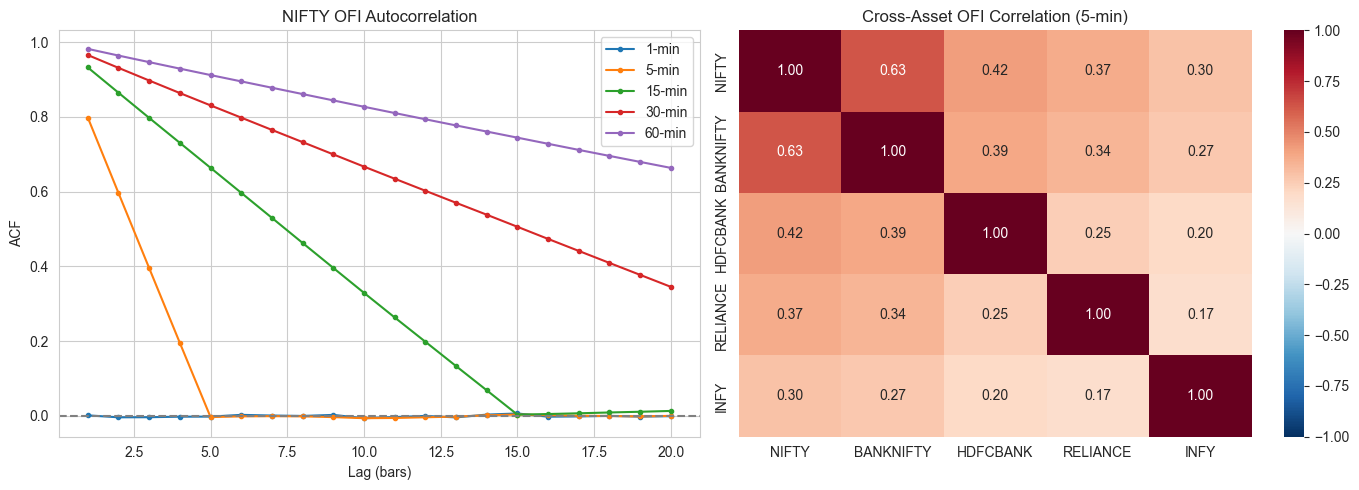

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h in OFI_HORIZONS:
    series = ofi_df[f'NIFTY_ofi_{h}'].dropna()
    acf_vals = [series.autocorr(lag=l) for l in range(1, 21)]
    axes[0].plot(range(1, 21), acf_vals, marker='o', markersize=3, label=f'{h}-min')

axes[0].set_title('NIFTY OFI Autocorrelation')
axes[0].set_xlabel('Lag (bars)')
axes[0].set_ylabel('ACF')
axes[0].legend()
axes[0].axhline(0, color='gray', linestyle='--')

# Cross-asset correlation at 5-min horizon
ofi_5min = ofi_df[[f'{t}_ofi_5' for t in TICKERS]].dropna()
ofi_5min.columns = TICKERS
sns.heatmap(ofi_5min.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Cross-Asset OFI Correlation (5-min)')

plt.tight_layout()
plt.savefig('../outputs/figures/ofi_autocorr_crosscorr.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 Save OFI data

In [7]:
from src.data_loader import save_processed

save_processed(ofi_df, name='ofi_all')
print('Saved OFI data to data/processed/ofi_all.parquet')

Saved OFI data to data/processed/ofi_all.parquet
